In [10]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
import math

In [11]:
sim = Simulation("RelativeTransmissivity")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# Enable overall relative transmissivity

sim["CCD/IncludeRelativeTransmissivity"] = "yes"

output = sim.run(removeOutputFile = True)


2020-06-03 14:56:20 WARNING Simulation: no information about detected stars to write to HDF5
2020-06-03 14:56:20 WARNING Camera: No star positions to write to HDF5 file.



In [12]:
pixelSize = sim["CCD/PixelSize"] / 1000.0    # Pixel size [mm]

In [13]:
image = output.getImage(0)
normalizationFactor = image[0][0]

image /= normalizationFactor

In [14]:
# Calculate the size of the FOV in pixels
fovDegrees = sim["CCD/RelativeTransmissivity/RadiusFOV"]
xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(fovDegrees), sim["Camera/FocalLength/ConstantValue"] * 1000, 0)     # Edge of the FOV along the x-axis
radiusPixels, zero = rf.focalPlaneToPixelCoordinates(xFP, yFP, sim["CCD/PixelSize"], 0, 0, 0)     # (size of the FOV, 0)
intersection = math.sqrt(radiusPixels**2 - sim["CCD/NumColumns"]**2)     # Where does the edge of the FOV intersect with the x-axis and the y-axis?

# Beyond the edge of the FOV

[Text(0, 0, ''),
 Text(0, 0, ''),
 Text(0, 0, '1000'),
 Text(0, 0, '2000'),
 Text(0, 0, '3000'),
 Text(0, 0, '4000'),
 Text(0, 0, ''),
 Text(0, 0, 'y$_{FOV}^*$'),
 Text(0, 0, 'R$_{FOV}$')]

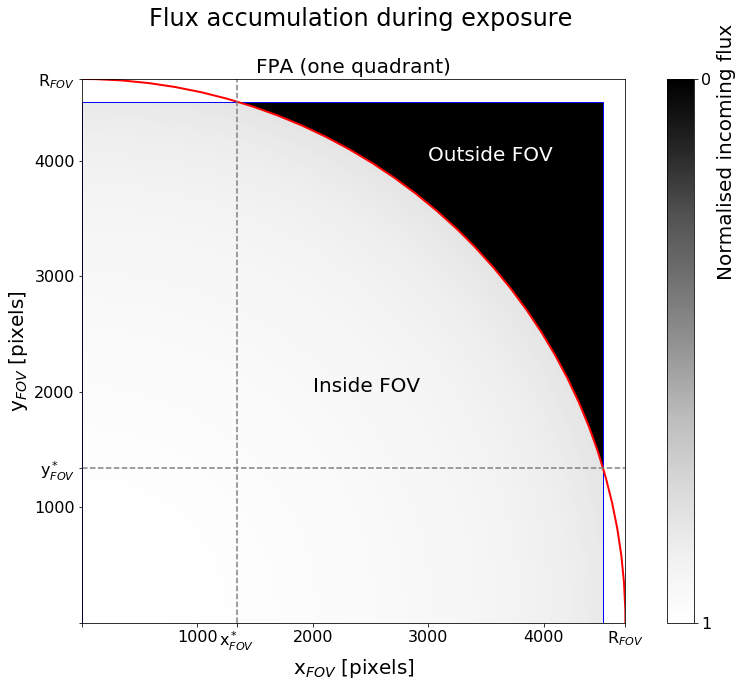

In [15]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



##########
# Detector
##########

rect = plt.Rectangle((0,0), sim["CCD/NumColumns"], sim["CCD/NumRows"])
ax.add_patch(rect)
rect.set_edgecolor("b")
rect.set_facecolor("none")



#####
# FOV
#####

circ = plt.Circle((0,0), radius = radiusPixels, color = "white", linewidth = 2)
ax.add_patch(circ)
circ.set_edgecolor("r")
circ.set_facecolor("none")



##########################
# Normalised incoming flux
##########################

im = plt.imshow(-image, origin='lower', cmap='Greys')



########
# Layout
########

plt.text(2000, 2000, "Inside FOV", fontsize = 20)
plt.text(3000, 4000, "Outside FOV", fontsize = 20, color = "w")

plt.suptitle("Flux accumulation during exposure", fontsize = 24)
plt.title("FPA (one quadrant)", fontsize = 20)
plt.xlabel("x$_{FOV}$ [pixels]", fontsize = 20)
plt.ylabel("y$_{FOV}$ [pixels]", fontsize = 20)

cbar = fig.colorbar(im, ticks=[-1, 0])
cbar.ax.set_yticklabels(['1', '0'], fontsize = 16)  # vertically oriented colorbar

plt.text(5500, 3000, "Normalised incoming flux", fontsize = 20, rotation = 90)

plt.axvline(x = intersection, linestyle = "--", color =  "gray")
plt.axhline(y = intersection, linestyle = "--", color =  "gray")

plt.xticks(list(plt.xticks()[0]) + [intersection, radiusPixels])
plt.yticks(list(plt.yticks()[0]) + [intersection, radiusPixels])
plt.xlim([0, radiusPixels])
plt.ylim([0, radiusPixels])

labels = [item.get_text() for item in ax.get_xticklabels()]
labels[2] = '1000'
labels[3] = '2000'
labels[4] = '3000'
labels[5] = '4000'
labels[7] = 'x$_{FOV}^*$'
labels[8] = 'R$_{FOV}$'
ax.set_xticklabels(labels, fontsize = 16)

labels[7] = 'y$_{FOV}^*$'
ax.set_yticklabels(labels, fontsize = 16)

(0, 0.19)

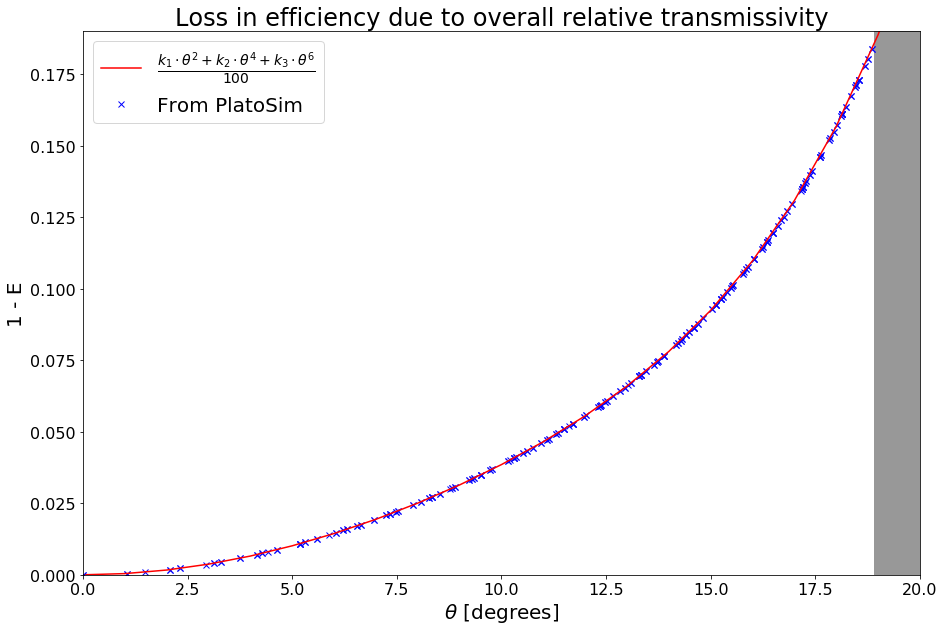

In [19]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

for row in range(0, sim["SubField/NumRows"], 250):
    
    for column in range(0, sim["SubField/NumColumns"], 250):
        
        # Calculate the angular distance of pixel (row, column) from the optical axis
        
        xFP, yFP = rf.pixelToFocalPlaneCoordinates(column, row, sim["CCD/PixelSize"], 0, 0, 0)     # Focal-plane coordinates[mm]
        distance = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(xFP, yFP, sim["Camera/FocalLength/ConstantValue"] * 1000))     # Angular distance from the OA [degrees]
        
        try:
            plt.plot([distance], 1 - image[row][column], "bx")
        except:
            pass

        

###########################
# From PLATO-INAF-PL-RP-001
###########################

radialDistances = np.arange(25)
coefficients = sim["CCD/RelativeTransmissivity/Coefficients"]
model = coefficients[0] * np.power(radialDistances, 2) + coefficients[1] * np.power(radialDistances, 4) + coefficients[2] * np.power(radialDistances, 6)
plt.plot(radialDistances, model / 100, "r", label="$\\frac{k_1 \cdot \\theta^2 + k_2 \cdot \\theta^4 + k_3 \cdot \\theta^6}{100}$")
# plt.plot(radialDistances, np.sin(np.deg2rad(radialDistances))**2 / np.sin(np.deg2rad(fovDegrees))**2 * 0.1048, "r", label = "From PLATO-INAF-PL-RP-001")



################################
# Edge of the FOV (θ = 18.8908°)
################################

plt.axvspan(-1, 0, facecolor='0.2', alpha=0.5)
plt.axvspan(fovDegrees, 25, facecolor='0.2', alpha=0.5)



########
# Layout
########

plt.title("Loss in efficiency due to overall relative transmissivity", fontsize = 24)
plt.xlabel("$\\theta$ [degrees]", fontsize = 20)
plt.ylabel("1 - E", fontsize = 20)

plt.plot([0], [0], "bx", label = "From PlatoSim")
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

plt.xlim([0, 20])
plt.ylim([0, 0.19])

# Expected value

In [34]:
totalFlux = 0
totalNumPixels = 0

for row in range(0, sim["SubField/NumRows"]):
    
    for column in range(0, sim["SubField/NumColumns"]):
        
        if row**2 + column**2 <= radiusPixels**2:
            totalFlux += image[row, column]
            totalNumPixels += 1

In [35]:
print("Expected value:", totalFlux / totalNumPixels)
print("To compare with input value in the configuration file:", sim["CCD/RelativeTransmissivity/ExpectedValue"])

Expected value: 0.9223069322495778
To compare with input value in the configuration file: 0.92
